# Linear Regression — From Scratch


**Linear Regression:**
$$y = Xw + b$$
We want to find $w$ (and $b$) so predictions $\hat y$ are as close to $y$ as possible. "Close" usually means minimizing **Mean Squared Error**:
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(\hat y_i - y_i)^2$$

## Setup

Text(0.5, 1.0, 'Synthetic data')

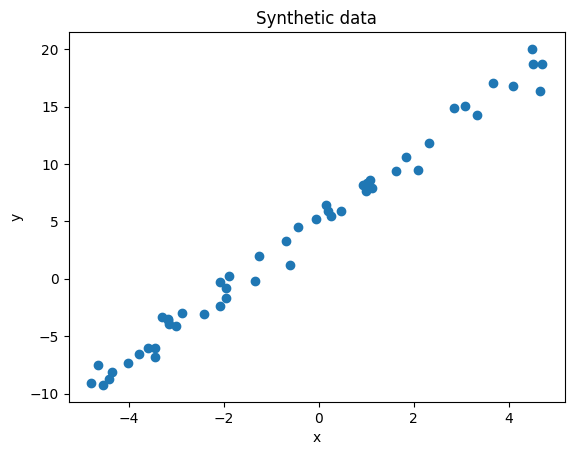

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# makes a generated amount of data (42 points)
np.random.seed(42)

def make_data(n=50, slope=3.0, intercept=5.0, noise=1.0):
    """Generate y = slope*x + intercept + noise."""
    x = np.random.uniform(-5, 5, size=n)
    y = slope * x + intercept + np.random.normal(0, noise, size=n)
    return x, y

x, y = make_data()
plt.scatter(x, y); plt.xlabel('x'); plt.ylabel('y'); plt.title('Synthetic data')

## Step 1 — Closed-Form Solution (Normal Equation)

Linear regression has an *exact* solution:
$$w = (X^T X)^{-1} X^T y$$

**Trick:** to learn the intercept as part of $w$, add a column of 1s to $X$. Then $w$ has shape `(n_features + 1,)` and the first element is the intercept.



Intercept: 4.985  (true: 5.0)
Slope:     2.978  (true: 3.0)


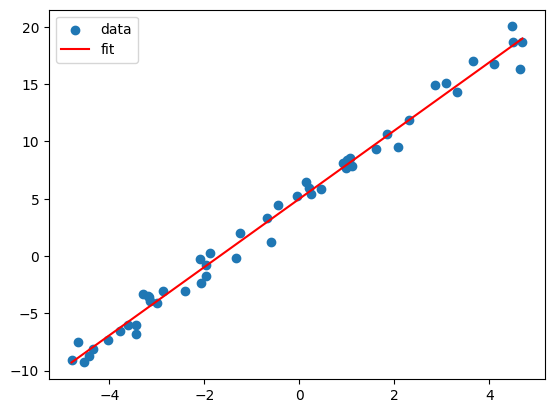

In [3]:
# Reshape x to a 2D column and prepend a 1s column for the bias
X = np.column_stack([np.ones_like(x), x])  # shape: (n, 2)

# Normal equation
w_closed = np.linalg.inv(X.T @ X) @ X.T @ y
print(f'Intercept: {w_closed[0]:.3f}  (true: 5.0)')
print(f'Slope:     {w_closed[1]:.3f}  (true: 3.0)')

# Plot
plt.scatter(x, y, label='data')
xs = np.linspace(x.min(), x.max(), 100)
plt.plot(xs, w_closed[0] + w_closed[1]*xs, 'r-', label='fit')
plt.legend();

**Try it:** create a dataset where two features are nearly identical (collinear). Watch `X.T @ X` become near-singular and the solution blow up. This is *why* iterative methods exist.

In [4]:
# TODO: stack x and x + tiny_noise as two features, run the normal equation, observe instability

## Step 2 — Gradient Descent From Scratch

The single most important algorithm in ML. Instead of solving for $w$ directly, *iterate*:
$$w \leftarrow w - \eta \cdot \nabla_w \text{MSE}$$

The gradient of MSE with respect to $w$ is:
$$\nabla_w \text{MSE} = \frac{2}{n} X^T (Xw - y)$$

**Code structure:** wrap this in a class so we can reuse it. Open `linear_regression.py` and you'll see the same pattern as sklearn — `.fit(X, y)` then `.predict(X)`.

In [5]:
class LinearRegressionGD:
    def __init__(self, lr=0.01, n_epochs=1000):
        self.lr = lr
        self.n_epochs = n_epochs
        self.w = None
        self.loss_history = []

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        for epoch in range(self.n_epochs):
            y_pred = X @ self.w
            # TODO: compute gradient (2/n) * X.T @ (y_pred - y)
            grad = ...
            # TODO: update self.w
            self.w = ...
            # TODO: append MSE to self.loss_history
        return self

    def predict(self, X):
        return X @ self.w

# Train and compare to the closed-form solution
model = LinearRegressionGD(lr=0.05, n_epochs=500).fit(X, y)
print('GD weights:    ', model.w)
print('Closed-form:   ', w_closed)

plt.plot(model.loss_history); plt.xlabel('epoch'); plt.ylabel('MSE'); plt.title('Loss curve');

ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

**Experiment:** crank `lr` up to 1.0. What happens? Why?

## Step 3 — Stochastic / Mini-Batch GD

Real ML doesn't use full-batch gradient descent on big data — it samples. Two flavors:
- **SGD**: update on one random sample at a time.
- **Mini-batch**: update on a small batch (e.g., 32) at a time.

Add a `batch_size` argument to your `.fit()` method.

In [6]:
# TODO: extend LinearRegressionGD to support batch_size
# Hint: shuffle indices each epoch, then loop over batches inside the epoch.
# Compare loss curves for batch_size = n (full), 32 (mini), 1 (SGD).
pass

## Step 4 — Multivariate + Feature Scaling

Move from 1 feature to many. Then standardize: $x' = (x - \mu) / \sigma$.

Without scaling, features on different magnitudes (e.g., `age` in years vs `income` in dollars) create a stretched loss surface and gradient descent crawls.

In [7]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
X_real, y_real = data.data, data.target

# TODO: fit your LinearRegressionGD on X_real (without scaling) — note slow convergence
# TODO: standardize: X_scaled = (X_real - X_real.mean(0)) / X_real.std(0)
# TODO: fit again on X_scaled — note dramatically faster convergence
# TODO: plot both loss curves on the same axes

## Step 5 — Ridge and Lasso Regularization

Add a penalty on the size of $w$ to reduce overfitting.
- **Ridge**: $\text{MSE} + \lambda \|w\|_2^2$  → gradient adds $2\lambda w$. Shrinks coefficients.
- **Lasso**: $\text{MSE} + \lambda \|w\|_1$  → gradient adds $\lambda \cdot \text{sign}(w)$. Drives some coefficients to exactly zero (feature selection).

Generate data with 20 features where only 3 actually matter. Watch each method behave differently.

In [9]:
# TODO: add an `l2` (Ridge) and `l1` (Lasso) penalty arg to your gradient computation
# TODO: sweep lambda over [0.001, 0.01, 0.1, 1, 10] and plot coefficient values vs lambda
# (the classic 'regularization path' plot)

## Step 6 — Polynomial Regression

"Linear" means linear in the *parameters* $w$, not in $x$. Add polynomial features `[1, x, x², x³, …]` to $X$ and fit the same linear model.

Watch underfitting (`d=1`) → good fit (`d=3`) → overfitting (`d=15`).

In [10]:
# TODO: generate y = sin(x) + noise
# TODO: build polynomial features manually: np.column_stack([x**k for k in range(d+1)])
# TODO: fit your model for d in [1, 3, 9, 15] and plot all fits
# TODO: re-do with Ridge regularization on d=15 — does it tame the overfit?

## Step 7 — Diagnostics

A model isn't done until you've checked it. Metrics alone lie — diagnostic *plots* tell you why a model is wrong.

- $R^2 = 1 - \frac{\sum(y - \hat y)^2}{\sum(y - \bar y)^2}$
- MSE, MAE
- **Residual plot**: $y - \hat y$ vs $\hat y$. Should look like random noise. Any pattern means your model is missing structure.

In [11]:
# TODO: implement r2_score(y, y_pred), mse(y, y_pred), mae(y, y_pred) from scratch
# TODO: plot residuals vs predictions — verify they look like noise
# TODO: compare your weights against sklearn.linear_model.LinearRegression — they should match

## What's next

Once this notebook runs cleanly end-to-end and your `linear_regression.py` mirrors sklearn's API, move on to `logistic_regression/`. You'll reuse 90% of the gradient descent code — only the loss function and final activation change.